# pH dependence of experimentally measured redox potentials

This notebook reproduces the pH-dependence analysis of experimentally measured redox potentials represented through the Organic Flow Battery Ontology (OFBO) and accessed through Ontop.

The analysis retrieves experimentally generated redox potentials reported versus the standard hydrogen electrode (SHE), together with the pH of the chemical system used in the corresponding electrochemical measurement. Molecules with measurements at more than one pH are retained.

To isolate the common pH-dependent contribution while removing molecule-specific differences in absolute redox potential, redox potentials and pH values are centred independently for each molecule. A global linear regression is then fitted to the centred data.

The resulting slope is compared with the Nernstian value of −0.05916 V per pH unit expected for an ideal two-electron/two-proton redox process at 298 K.

## 1. Imports and Ontop connection

The Ontop endpoint exposes the OFBO virtual knowledge graph. The query results are returned as CSV and converted into a Pandas DataFrame.

In [ ]:
from io import StringIO
from collections import Counter

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from IPython.display import Markdown, display


ONTOP_ENDPOINT = "http://localhost:8080/sparql"
TIMEOUT_SECONDS = 120

## 2. SPARQL query

The query retrieves:

- a molecular SMILES representation;
- the experimentally measured redox potential;
- the pH of the chemical system used in the measurement; and
- the potential reference.

Only values measured in an experimental process and reported versus SHE are included. The query uses the full SMILES representation when available and otherwise falls back to the Core SMILES representation.

Core SMILES are modelled as a subproperty of `schema:smiles` in OFBO. The `OPTIONAL`, `FILTER`, and `COALESCE` pattern avoids returning both the complete molecular structure and its scaffold as separate identifiers.

In [17]:
query_file = Path("queries/query_nernst.rq")
query = query_file.read_text(encoding="utf-8")

display(Markdown(f"```sparql\n{query}\n```"))

```sparql
PREFIX ofbo:   <https://w3id.org/ofbo#>
PREFIX schema: <http://schema.org/>
PREFIX sio:    <http://semanticscience.org/resource/>
PREFIX prov:   <http://www.w3.org/ns/prov#>
PREFIX qudt:   <http://qudt.org/schema/qudt/>

SELECT DISTINCT
    ?smiles
    ?E
    ?pH
WHERE {
    ?molecule a ofbo:OFBO_0000012 ;
              ofbo:OFBO_0009101 ?coreSmiles ;
              ofbo:OFBO_0009206 ?reaction .

    # Prefer a molecular SMILES that differs from the Core SMILES.
    OPTIONAL {
        ?molecule schema:smiles ?fullSmiles .
        FILTER(?fullSmiles != ?coreSmiles)
    }

    # Use the Core SMILES only when no distinct full SMILES is available.
    BIND(COALESCE(?fullSmiles, ?coreSmiles) AS ?smiles)

    ?redoxPotential a ofbo:OFBO_0001104 ;
                    sio:SIO_000011 ?reaction ;
                    qudt:numericValue ?E ;
                    ofbo:OFBO_0009202 "SHE" ;
                    prov:wasGeneratedBy ?experiment .

    ?experiment a ofbo:OFBO_0008500 ;
                prov:used ?system .

    ?system sio:SIO_000223 ?pHProperty .

    ?pHProperty a ofbo:OFBO_0001016 ;
                qudt:numericValue ?pH .
}
ORDER BY ?smiles ?pH
```

## 3. Execute the query and prepare the dataset

The query result is exported as `nernst.csv` to provide a reusable intermediate dataset. The CSV file contains three columns:

- `smiles`: molecular identifier;
- `E`: experimental redox potential in V versus SHE;
- `pH`: pH of the measurement system.

In [18]:
from pathlib import Path
from io import StringIO

response = requests.post(
    ONTOP_ENDPOINT,
    data={"query": query},
    headers={"Accept": "text/csv"},
    timeout=TIMEOUT_SECONDS,
)

response.raise_for_status()

df = pd.read_csv(StringIO(response.text))

df["pH"] = pd.to_numeric(df["pH"], errors="coerce")
df["E"] = pd.to_numeric(df["E"], errors="coerce")
df["smiles"] = df["smiles"].str.strip()

df = df.dropna(subset=["smiles", "E", "pH"]).copy()
df = df.drop_duplicates(subset=["smiles", "E", "pH"]).copy()

# Exclude the 1.21 V measurement: it represents phenolic oxidation
# rather than the quinone/hydroquinone redox reaction used in this analysis.
df = df.loc[~np.isclose(df["E"], 1.21, atol=1e-2)].copy()

df.to_csv("nernst.csv", index=False, header=False)

print(f"Retrieved {len(df)} unique redox-potential measurements.")
print(f"Retrieved {df['smiles'].nunique()} unique molecular identifiers.")
print("Excluded redox potentials at 1.21 V.")

df.head()

Retrieved 148 unique redox-potential measurements.
Retrieved 83 unique molecular identifiers.
Excluded redox potentials at 1.21 V.


,smiles,E,pH
0,C/C(=C\C(=O)O)c1ccc2c(c1)C(=O)c1ccc(/C(C)=C/C(...,-0.4300,14
1,CC(C)(CC(=O)O)c1ccc2c(c1C(C)(C)CC(=O)O)C(=O)c1...,-0.4990,14
2,CC(C)=CCC1=C(O)c2ccccc2C(=O)C1=O,0.3333,0
3,CC(C)=CCC1=C(O)c2ccccc2C(=O)C1=O,-0.1287,7
4,CC(C)=CCC1=C(O)c2ccccc2C(=O)C1=O,-0.4330,13


## 4. Select molecules measured at multiple pH values

Only molecules with measurements at more than one pH value can contribute to the pH-dependence analysis.

In [19]:
counts = Counter(df["smiles"])
multi_ph_smiles = [smiles for smiles, count in counts.items() if count > 1]

df_multi = df[df["smiles"].isin(multi_ph_smiles)].copy()

print(f"Molecules measured at multiple pH values: {df_multi['smiles'].nunique()}")
print(f"Measurements retained for regression: {len(df_multi)}")

df_multi.head()

Molecules measured at multiple pH values: 32
Measurements retained for regression: 97


,smiles,E,pH
2,CC(C)=CCC1=C(O)c2ccccc2C(=O)C1=O,0.3333,0
3,CC(C)=CCC1=C(O)c2ccccc2C(=O)C1=O,-0.1287,7
4,CC(C)=CCC1=C(O)c2ccccc2C(=O)C1=O,-0.4330,13
8,COc1ccc2c(c1)C(=O)c1cnncc1C2=O,0.5380,0
9,COc1ccc2c(c1)C(=O)c1cnncc1C2=O,-0.0880,14


## 5. Centre values and fit the global regression model

For each molecule, its mean redox potential and mean pH are subtracted from the corresponding measurements. This removes molecule-specific offsets and permits estimation of the shared pH-dependent trend across the molecular dataset.

In [20]:
df_multi["E_centered"] = df_multi.groupby("smiles")["E"].transform(
    lambda values: values - values.mean()
)

df_multi["pH_centered"] = df_multi.groupby("smiles")["pH"].transform(
    lambda values: values - values.mean()
)

x = df_multi["pH_centered"].values
y = df_multi["E_centered"].values

A = np.vstack([x, np.ones(len(x))]).T
slope, intercept = np.linalg.lstsq(A, y, rcond=None)[0]

y_pred = intercept + slope * x

ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

residuals = y - y_pred
mae = np.mean(np.abs(residuals))

n_points = len(x)
df_dof = n_points - 2

sigma2 = np.sum(residuals ** 2) / df_dof
sigma = np.sqrt(sigma2)

x_mean = np.mean(x)
Sxx = np.sum((x - x_mean) ** 2)

slope_se = np.sqrt(sigma2 / Sxx)
t_crit = stats.t.ppf(0.975, df_dof)
slope_ci = t_crit * slope_se

n_electrons = 2
m_over_n = -slope / 0.05916
m_protons = m_over_n * n_electrons

print(f"Global Nernst slope (centered): {slope:.5f} V/pH")
print(f"Intercept (centered): {intercept:.5f} V")
print(f"R² (centered): {r2:.4f}")
print(f"MAE: {mae * 1000:.1f} mV")
print(f"Slope: {slope:.5f} ± {slope_se:.5f} V/pH (standard error)")
print(f"Slope (95% CI): {slope:.5f} ± {slope_ci:.5f} V/pH")
print(f"Effective protons per two electrons: m = {m_protons:.2f}")

Global Nernst slope (centered): -0.04982 V/pH
Intercept (centered): 0.00000 V
R² (centered): 0.9322
MAE: 56.6 mV
Slope: -0.04982 ± 0.00138 V/pH (standard error)
Slope (95% CI): -0.04982 ± 0.00274 V/pH
Effective protons per two electrons: m = 1.68


## 6. Plot the centred pH dependence

Each colour represents one molecule. The dashed black line is the global least-squares fit across all centred measurements.

Optionally, setting `Nernst = True` overlays the ideal Nernstian slope of −0.05916 V/pH as a red line.

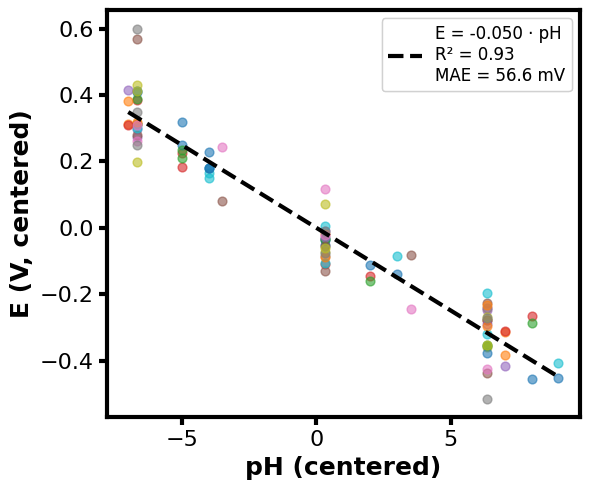

In [22]:
Nernst = False

plt.figure(figsize=(6, 5))
ax = plt.gca()

ph_range = np.linspace(
    df_multi["pH_centered"].min(),
    df_multi["pH_centered"].max(),
    200,
)

y_fit = intercept + slope * ph_range

# Plot centred measurements for each molecule.
for smiles, group in df_multi.groupby("smiles"):
    ax.scatter(
        group["pH_centered"],
        group["E_centered"],
        s=40,
        alpha=0.6,
        label=smiles,
    )

# Plot global fit.
line_fit, = ax.plot(
    ph_range,
    y_fit,
    "k--",
    linewidth=3,
    label=None,
)

# Optional ideal Nernst slope.
if Nernst:
    theoretical_slope = -0.05916
    theoretical_intercept = 0.0
    y_theory = theoretical_intercept + theoretical_slope * ph_range

    line_theory, = ax.plot(
        ph_range,
        y_theory,
        color="red",
        linewidth=2.5,
        linestyle="-",
    )

    theory_legend = ax.legend(
        [line_theory],
        ["Nernst equation"],
        loc="upper left",
        fontsize=12,
    )
    ax.add_artist(theory_legend)

# Axis styling.
ax.set_xlabel("pH (centered)", fontsize=18, fontweight="bold")
ax.set_ylabel(r"E (V, centered)", fontsize=18, fontweight="bold")

ax.tick_params(axis="both", labelsize=16, width=3, length=6)

for spine in ax.spines.values():
    spine.set_linewidth(3)

ax.grid(False)

# Regression statistics legend.
fit_legend = ax.legend(
    [line_fit],
    [
        f"E = {slope:.3f} · pH\n"
        f"R² = {r2:.2f}\n"
        f"MAE = {mae * 1000:.1f} mV"
    ],
    loc="upper right",
    fontsize=12,
)
ax.add_artist(fit_legend)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig("nernst_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Interpretation

The fitted slope quantifies the shared pH dependence of the redox potentials after molecule-specific offsets have been removed by group centring.

For an ideal two-electron/two-proton redox process at 298 K, the expected Nernstian slope is −0.05916 V/pH. Deviations from this value can reflect non-ideal proton coupling, protonation equilibria, solvent effects, or differences in the electrochemical processes represented across the integrated studies.

The query demonstrates that the OFBO–OBDA framework can retrieve experimental redox potentials together with their associated chemical-system pH values across independently curated datasets. The subsequent centring, regression, and visualization are performed in Python.